In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pylab import mpl
# 设置中文显示字体
mpl.rcParams["font.sans-serif"] = ["SimHei"]
from fast_kurtogram import Fast_Kurtogram # 导入你提供的代码
from scipy import signal
from scipy.linalg import toeplitz
import scipy.io as scio

C:\Users\wwt12\AppData\Local\Temp\ipykernel_20192\2370011899.py:68: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  plt.tight_layout()


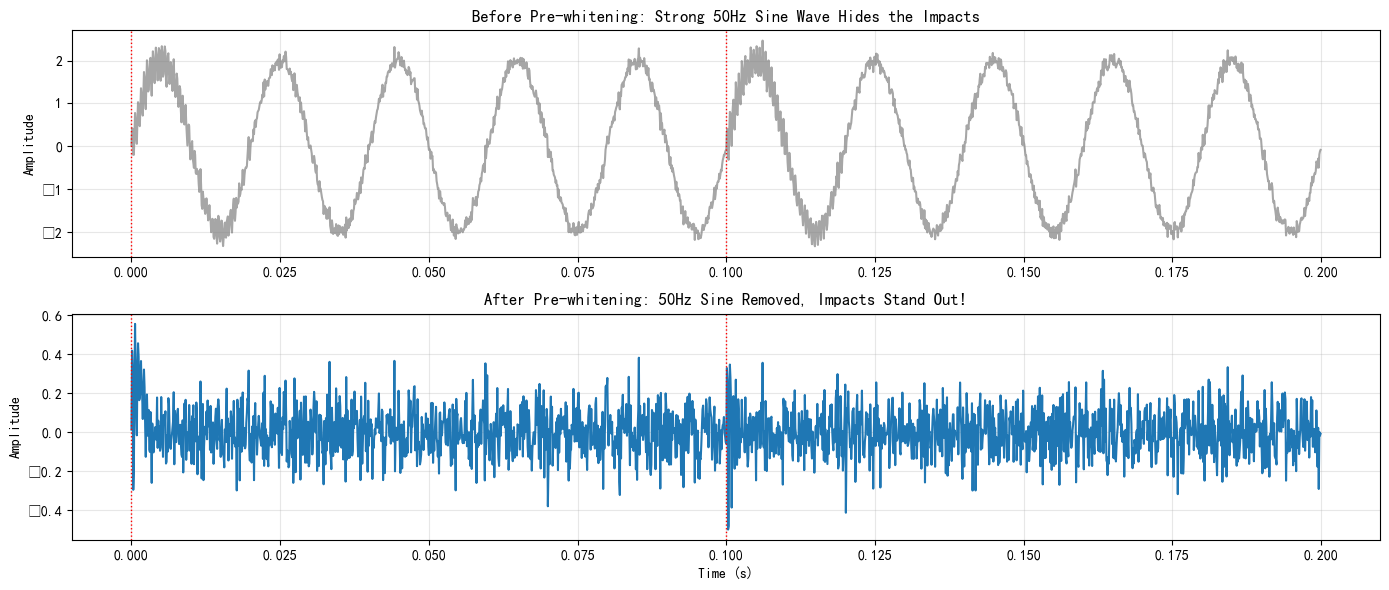

观察重点：
1. 上图：巨大的正弦波淹没了微小的红色冲击。
2. 下图：正弦波几乎消失（变成接近 0 的直线），红色的冲击脉冲清晰可见。


In [13]:


def ar_prewhiten_demo(y, order=20):
    """简单的 AR 预白化实现"""
    # 1. 计算自相关
    r = np.correlate(y, y, mode='full')[len(y)-1 : len(y)+order]
    # 2. 求解 Yule-Walker 方程 (Toeplitz 矩阵)
    try:
        R = toeplitz(r[:-1])
        R += np.eye(order) * 1e-9 # 正则化防止奇异
        a = np.linalg.solve(R, -r[1:])
    except:
        return y # 失败则返回原信号
    
    ar_coeffs = np.concatenate(([1], a))
    # 3. 滤波得到残差
    residual = signal.lfilter(ar_coeffs, [1], y)
    return residual

# --- 构造模拟数据 ---
fs = 10000
t = np.linspace(0, 1, fs)

# A. 强周期干扰 (模拟齿轮啮合，频率 50Hz)
interference = 2.0 * np.sin(2 * np.pi * 50 * t) 

# B. 微弱轴承冲击 (模拟每 0.1 秒一次冲击，频率 10Hz)
# 创建一个脉冲序列
impulse_train = np.zeros_like(t)
impulse_indices = np.arange(0, len(t), int(fs/10)) # 10Hz
# 给每个冲击点加一个衰减振荡波形
for idx in impulse_indices:
    if idx < len(t):
        end_idx = min(idx + 200, len(t))
        decay_t = np.arange(end_idx - idx) / fs
        impulse_train[idx:end_idx] += 0.5 * np.exp(-50 * decay_t) * np.sin(2 * np.pi * 2000 * decay_t)

# C. 混合信号 (干扰 >> 冲击)
raw_signal = interference + impulse_train + 0.1 * np.random.randn(len(t))

# --- 执行预白化 ---
whitened_signal = ar_prewhiten_demo(raw_signal, order=30)

# --- 绘图对比 ---
plt.figure(figsize=(14, 6))

# 子图 1: 原始信号 (只看前 0.2 秒)
plt.subplot(2, 1, 1)
plt.plot(t[:2000], raw_signal[:2000], label='Raw Signal (Interference + Impact)', color='gray', alpha=0.7)
plt.title('Before Pre-whitening: Strong 50Hz Sine Wave Hides the Impacts')
plt.ylabel('Amplitude')
plt.grid(True, alpha=0.3)
# 标记冲击位置
for idx in impulse_indices[:3]:
    if idx < 2000:
        plt.axvline(t[idx], color='red', linestyle=':', linewidth=1)

# 子图 2: 预白化后
plt.subplot(2, 1, 2)
plt.plot(t[:2000], whitened_signal[:2000], label='Whitened Residual', color='#1f77b4')
plt.title('After Pre-whitening: 50Hz Sine Removed, Impacts Stand Out!')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True, alpha=0.3)
# 标记冲击位置
for idx in impulse_indices[:3]:
    if idx < 2000:
        plt.axvline(t[idx], color='red', linestyle=':', linewidth=1)

plt.tight_layout()
plt.show()

print("观察重点：")
print("1. 上图：巨大的正弦波淹没了微小的红色冲击。")
print("2. 下图：正弦波几乎消失（变成接近 0 的直线），红色的冲击脉冲清晰可见。")

C:\Users\wwt12\AppData\Local\Temp\ipykernel_20192\721711197.py:46: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  plt.tight_layout()
E:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


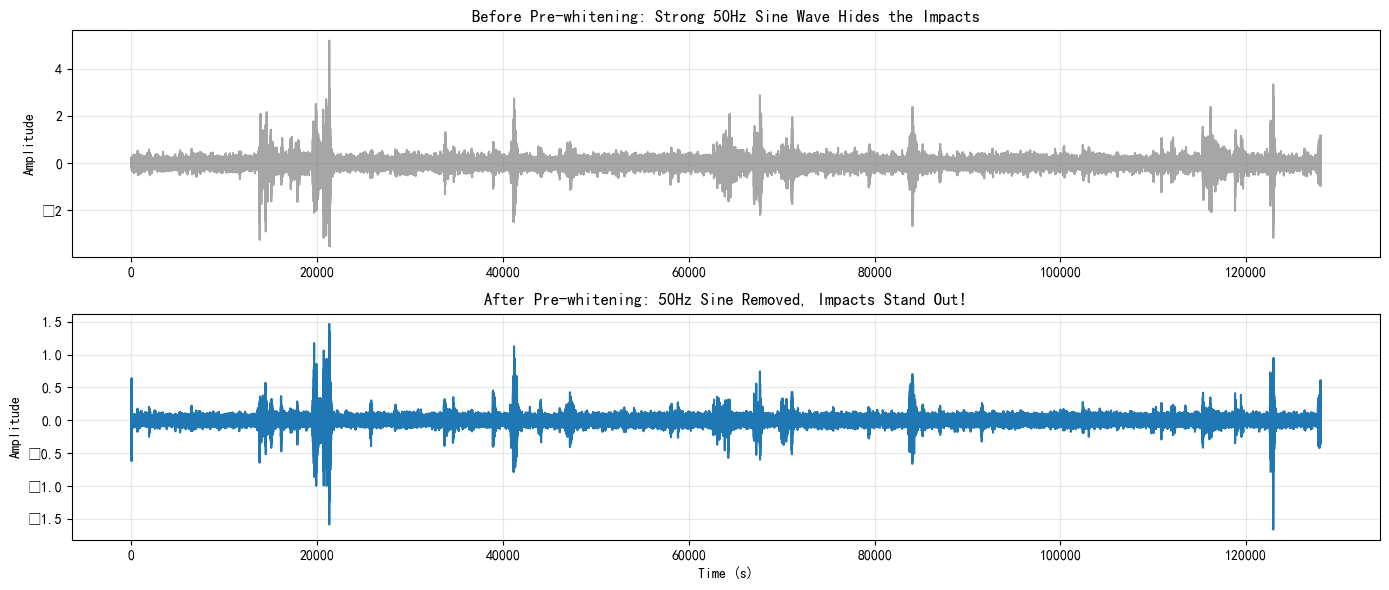

In [14]:
import pandas as pd
def ar_prewhiten_demo(y, order=20):
    """简单的 AR 预白化实现"""
    # 1. 计算自相关
    r = np.correlate(y, y, mode='full')[len(y)-1 : len(y)+order]
    # 2. 求解 Yule-Walker 方程 (Toeplitz 矩阵)
    try:
        R = toeplitz(r[:-1])
        R += np.eye(order) * 1e-9 # 正则化防止奇异
        a = np.linalg.solve(R, -r[1:])
    except:
        return y # 失败则返回原信号
    
    ar_coeffs = np.concatenate(([1], a))
    # 3. 滤波得到残差
    residual = signal.lfilter(ar_coeffs, [1], y)
    return residual

raw_signal=pd.read_csv('../数据集/BJTU/滚动体/data_leftaxlebox_M0_G0_LA3_RA0_20Hz_-10kN.csv',usecols=['CH17']).values
raw_signal = raw_signal.flatten() 
raw_signal=raw_signal[:128000]

# --- 执行预白化 ---
whitened_signal = ar_prewhiten_demo(raw_signal, order=30)
# --- 绘图对比 ---
plt.figure(figsize=(14, 6))

# 子图 1: 原始信号 (只看前 0.2 秒)
plt.subplot(2, 1, 1)
plt.plot(raw_signal, label='Raw Signal (Interference + Impact)', color='gray', alpha=0.7)
plt.title('Before Pre-whitening: Strong 50Hz Sine Wave Hides the Impacts')
plt.ylabel('Amplitude')
plt.grid(True, alpha=0.3)
# 标记冲击位置


# 子图 2: 预白化后
plt.subplot(2, 1, 2)
plt.plot( whitened_signal, label='Whitened Residual', color='#1f77b4')
plt.title('After Pre-whitening: 50Hz Sine Removed, Impacts Stand Out!')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

这张图展示了真实轴承振动信号在经过 AR 预白化（Pre-whitening） 处理前后的对比。这是一个非常成功的故障诊断预处理案例。

以下是对这张图的详细专业分析：

总体结论
预白化效果显著。
原始信号中混杂了大量的背景噪声和可能的周期性干扰，导致微弱的冲击特征被淹没。经过 p=30 阶的 AR 模型处理后，背景变得平坦（白噪声化），原本隐藏在深处的瞬态冲击（Impacts）清晰地浮现出来。这为后续的谱峭度分析和包络解调打下了完美的基础。

上图分析：原始信号 (Before Pre-whitening)
视觉特征：
    信号整体看起来像是一团“毛刺”，振幅主要在 pm 0.5 之间波动。
    虽然能看到几个明显的尖峰（例如在采样点 10,000、55,000、110,000 附近），但它们的周围充满了杂乱的波动。
    信噪比 (SNR) 低：很难一眼判断这些尖峰是真实的轴承损伤冲击，还是随机的大噪声，或者是齿轮啮合产生的调制波。
物理含义：
    这是典型的工业现场数据。包含了传感器底噪、结构传递的背景振动、以及可能存在的轴转频或齿轮啮合频率分量。
    如果不进行处理直接做频谱分析，这些强背景能量会形成很高的“噪声地板”，掩盖微弱的故障特征频率。

下图分析：预白化后信号 (After Pre-whitening)
视觉特征：
    背景极度平坦：除了那几个尖峰外，其余部分的信号振幅被压缩到了 pm 0.2 甚至更小，且分布非常均匀。这说明 AR 模型成功预测并减去了信号中的确定性周期分量（如旋转部件的规律振动）。
    冲击特征突出：原本模糊的尖峰现在变成了清晰的双极性脉冲（先正后负或先负后正的振荡波形）。
        注意看采样点 110,000 附近的冲击，其形态非常完整，呈现出典型的衰减振荡形状（这是冲击激发结构共振的典型表现）。
        在 55,000 和 10,000 附近也有成组的冲击出现。
物理含义：
    残留下来的这些尖峰，就是不可预测的随机瞬态事件。在轴承诊断语境下，这极大概率就是滚动体或滚道损伤产生的周期性冲击。
    由于去除了强干扰，现在的信号更接近于“白噪声 + 冲击”，这正是计算谱峭度 (Spectral Kurtosis) 的理想输入。

关键细节解读

A. 为什么冲击是“一簇一簇”的？
仔细观察下图，冲击并不是单个孤立的点，而是一段短暂的振荡（例如在 110,000 点处，持续了约 2000-3000 个采样点）。
解释：这是因为轴承损伤产生的瞬间力是一个宽频带的脉冲，它激发了传感器或轴承座结构的固有频率（共振）。
意义：这段振荡的持续时间对应了系统的阻尼特性。这也验证了为什么我们需要做带通滤波（下一步骤）——我们需要提取这段振荡所在的频段，而不是整个频带。

B. 参数 p=30 合适吗？
判断：非常合适。
理由：
    如果 p 太小，背景不会这么平坦，还会残留正弦波。
    如果 p 太大，这些清晰的冲击波形会被“削平”或消失（被误认为是周期信号而被减去）。
    现在的图中，冲击保留得非常完整，说明 p=30 刚好捕捉到了背景规律，而没有过拟合到冲击本身。



#鞘度谱

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pylab import mpl
# 设置中文显示字体
mpl.rcParams["font.sans-serif"] = ["SimHei"]
from fast_kurtogram import Fast_Kurtogram # 导入你提供的代码
from scipy import signal
from scipy.linalg import toeplitz

In [16]:

def ar_prewhiten_demo(y, order=20):
    """简单的 AR 预白化实现"""
    # 1. 计算自相关
    r = np.correlate(y, y, mode='full')[len(y)-1 : len(y)+order]
    # 2. 求解 Yule-Walker 方程 (Toeplitz 矩阵)
    try:
        R = toeplitz(r[:-1])
        R += np.eye(order) * 1e-9 # 正则化防止奇异
        a = np.linalg.solve(R, -r[1:])
    except:
        return y # 失败则返回原信号


    ar_coeffs = np.concatenate(([1], a))
    # 3. 滤波得到残差
    residual = signal.lfilter(ar_coeffs, [1], y)
    return residual

def fast_kurtogram(data,fs):
    print("--- 开始谱峭度自动检测 ---")
    data = data.flatten()
    print("--- 开始预白化 ---")
    data = ar_prewhiten_demo(data, order=30)
    # 4. 调用你提供的 Fast_Kurtogram 函数
    # nlevel=4 代表分解深度，通常 3-5 层足够
    Kwav, Level_w, freq_w, c, f_low, f_high = Fast_Kurtogram(
        data, nlevel=4, Fs=fs, verbose=False
    )
    
    print(f"检测完成！")
    print(f"自动锁定的共振频带: {f_low} Hz - {f_high} Hz")
    
    # 5. 对提取出的复包络 c 进行包络谱分析 (验证故障频率)
    # c 是滤波后的复信号包络
    envelope = np.abs(c)
    # 去除直流分量后做 FFT
    env_fft = np.abs(np.fft.rfft(envelope - np.mean(envelope)))
    env_freqs = np.fft.rfftfreq(len(envelope), 1/(fs / (len(raw_signal)/len(c))))
    
    return  Kwav, env_fft, env_freqs



In [17]:
# 6. 绘图展示
def plot_diagnosti(Kwav, env_fft, env_freqs):
    plt.figure(figsize=(12, 10))
    
    # 时域对比
    plt.subplot(3, 1, 1)
    plt.plot( raw_signal, color='gray', alpha=0.6)
    plt.title("原始含噪信号 (肉眼难以观察冲击)")
    
    # 谱峭度图 (Kurtogram) - 这里我们手动画一下简单版，或者你可以开启 verbose=True
    plt.subplot(3, 1, 2)
    plt.imshow(Kwav, aspect='auto', cmap='jet', extent=[0, fs/2, 4, 0])
    plt.colorbar(label='Kurtosis Value')
    plt.title("谱峭度图 (Kurtogram) - 颜色越红代表冲击特征越强")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Level")
    
    # 包络谱验证
    plt.subplot(3, 1, 3)
    plt.plot(env_freqs, env_fft, color='red')
    # for i in range(1,4):
    #     plt.axvline(fault_freq*i, color='green', linestyle='--', label=f'Fault Frequency ({fault_freq*i}Hz)')
    plt.xlim(0, 140) # 只看低频故障区
    plt.title("滤波后信号的包络谱")
    plt.xlabel("Frequency (Hz)")
    plt.legend()
    
    plt.tight_layout()
    plt.show()

--- 开始谱峭度自动检测 ---
--- 开始预白化 ---
检测完成！
自动锁定的共振频带: 12032.0 Hz - 14016.0 Hz


C:\Users\wwt12\AppData\Local\Temp\ipykernel_20192\2339610408.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\wwt12\AppData\Local\Temp\ipykernel_20192\2339610408.py:28: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  plt.tight_layout()
E:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


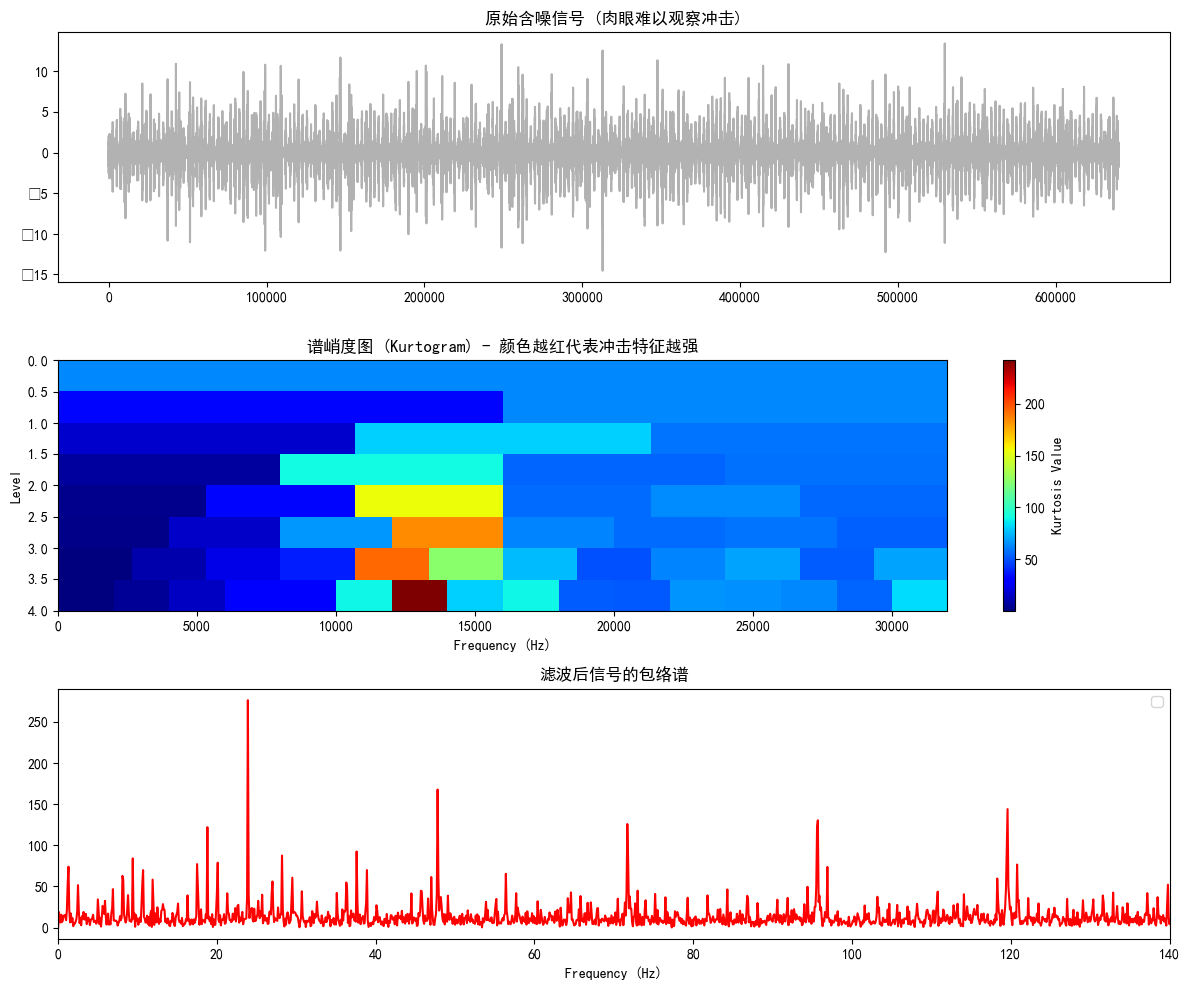

In [18]:

# 1. 参数设置
fs = 64000              # 采样频率 20kHz
fault_freq = 9.7         # 模拟轴承故障频率 (如 BPFO = 80Hz)
raw_signal=pd.read_csv('../数据集/BJTU/外圈加滚动体/data_leftaxlebox_M0_G0_LA2+LA3_RA0_20Hz_-10kN.csv',usecols=['CH17']).values
raw_signal = raw_signal.flatten() 
raw_signal=raw_signal

Kwav, env_fft, env_freqs=fast_kurtogram(raw_signal, fs)
plot_diagnosti(Kwav, env_fft, env_freqs)

--- 开始谱峭度自动检测 ---
--- 开始预白化 ---
检测完成！
自动锁定的共振频带: 19968.0 Hz - 24000.0 Hz


C:\Users\wwt12\AppData\Local\Temp\ipykernel_20192\2339610408.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\wwt12\AppData\Local\Temp\ipykernel_20192\2339610408.py:28: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  plt.tight_layout()
E:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


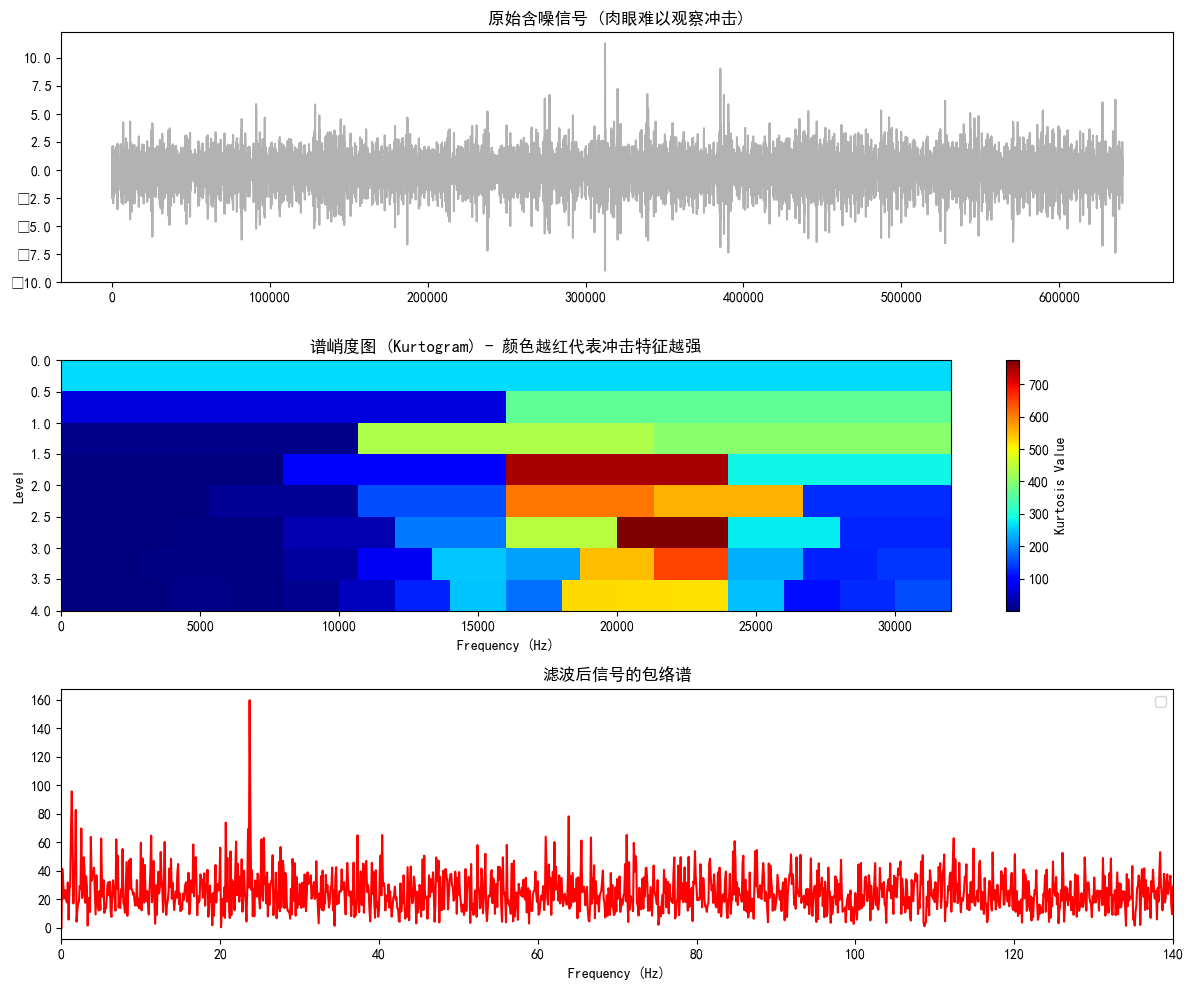

In [19]:
# 1. 参数设置
fs = 64000 
raw_signal=pd.read_csv('../数据集/BJTU/外圈加滚动体/data_leftaxlebox_M0_G0_LA2+LA3_RA0_20Hz_0kN.csv',usecols=['CH17']).values
raw_signal = raw_signal.flatten() 
raw_signal=raw_signal

Kwav, env_fft, env_freqs=fast_kurtogram(raw_signal, fs)
plot_diagnosti(Kwav, env_fft, env_freqs)

--- 开始谱峭度自动检测 ---
--- 开始预白化 ---
检测完成！
自动锁定的共振频带: 16000.0 Hz - 24000.0 Hz


C:\Users\wwt12\AppData\Local\Temp\ipykernel_20192\2339610408.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\wwt12\AppData\Local\Temp\ipykernel_20192\2339610408.py:28: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  plt.tight_layout()
E:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


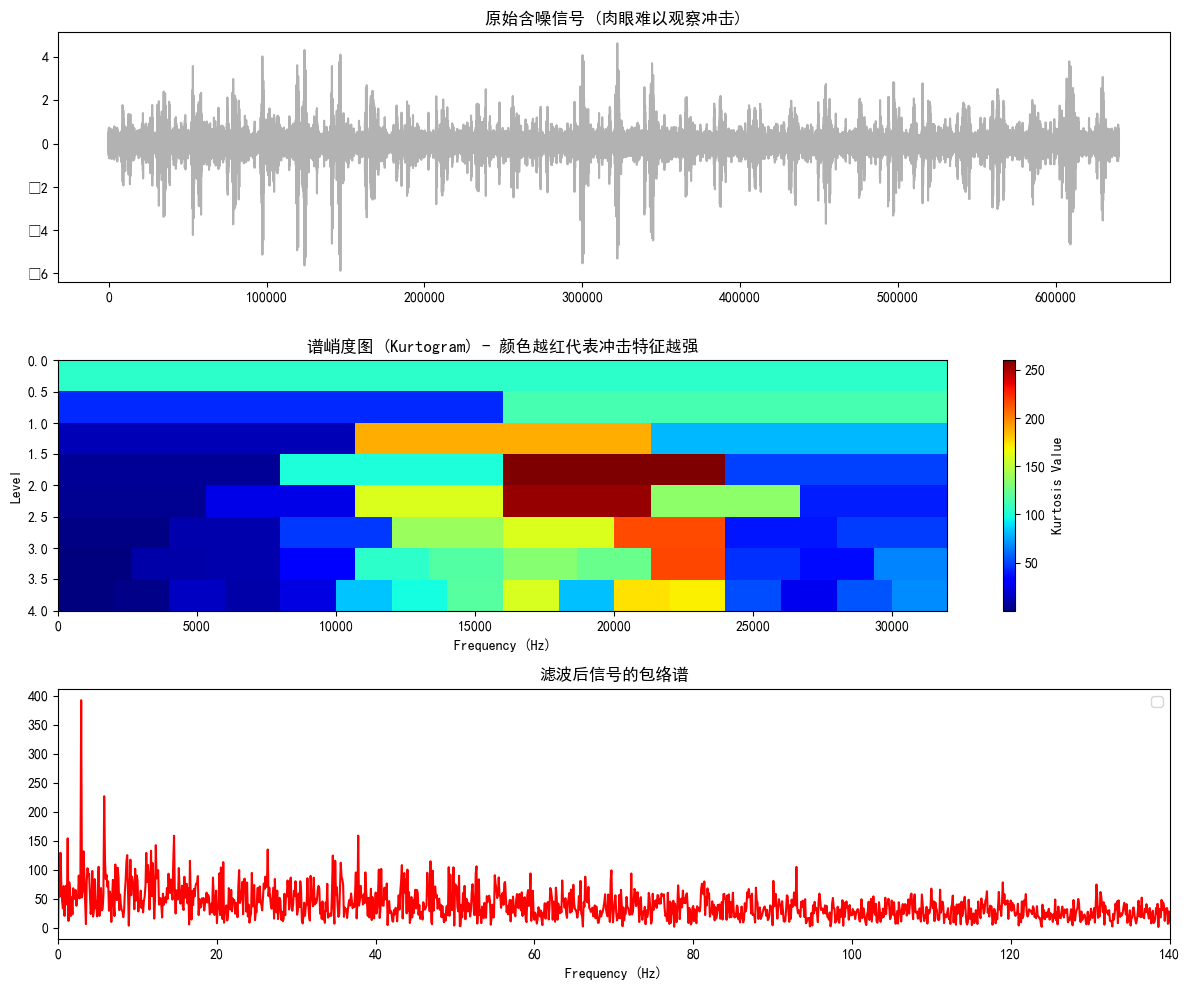

In [20]:
# 1. 参数设置
fs = 64000 
raw_signal=pd.read_csv('../数据集/BJTU/外圈加滚动体/data_leftaxlebox_M0_G0_LA2+LA3_RA0_20Hz_+10kN.csv',usecols=['CH17']).values
raw_signal = raw_signal.flatten() 
raw_signal=raw_signal

Kwav, env_fft, env_freqs=fast_kurtogram(raw_signal, fs)
plot_diagnosti(Kwav, env_fft, env_freqs)

--- 开始谱峭度自动检测 ---
--- 开始预白化 ---
检测完成！
自动锁定的共振频带: 12032.0 Hz - 16000.0 Hz


C:\Users\wwt12\AppData\Local\Temp\ipykernel_20192\2339610408.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\wwt12\AppData\Local\Temp\ipykernel_20192\2339610408.py:28: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  plt.tight_layout()
E:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


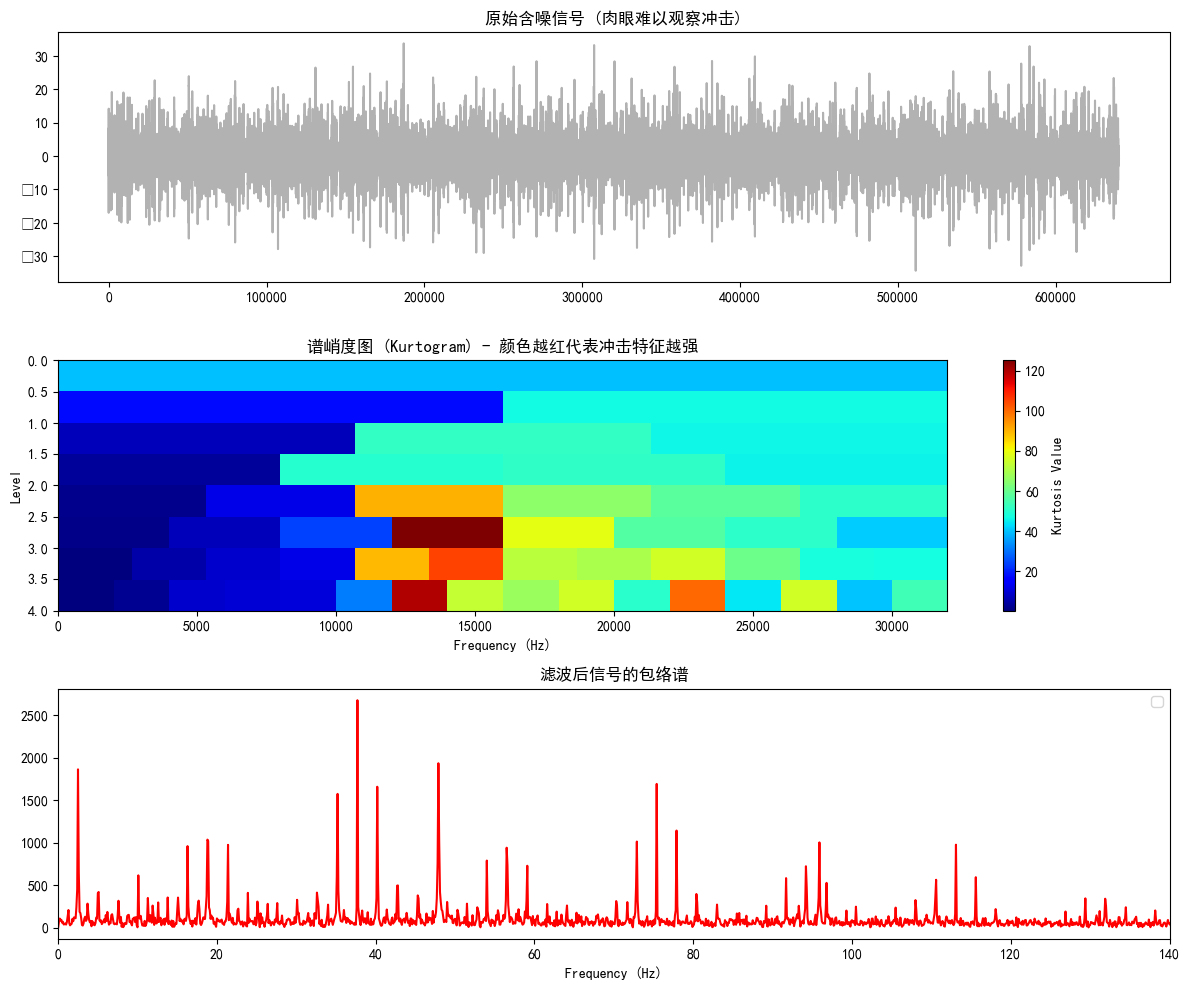

In [21]:
# 1. 参数设置
fs = 64000 
raw_signal=pd.read_csv('../数据集/BJTU/外圈加滚动体/data_leftaxlebox_M0_G0_LA2+LA3_RA0_40Hz_-10kN.csv',usecols=['CH17']).values
raw_signal = raw_signal.flatten() 
raw_signal=raw_signal

Kwav, env_fft, env_freqs=fast_kurtogram(raw_signal, fs)
plot_diagnosti(Kwav, env_fft, env_freqs)

--- 开始谱峭度自动检测 ---
--- 开始预白化 ---
检测完成！
自动锁定的共振频带: 18688.0 Hz - 21312.0 Hz


C:\Users\wwt12\AppData\Local\Temp\ipykernel_20192\2339610408.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\wwt12\AppData\Local\Temp\ipykernel_20192\2339610408.py:28: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  plt.tight_layout()
E:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


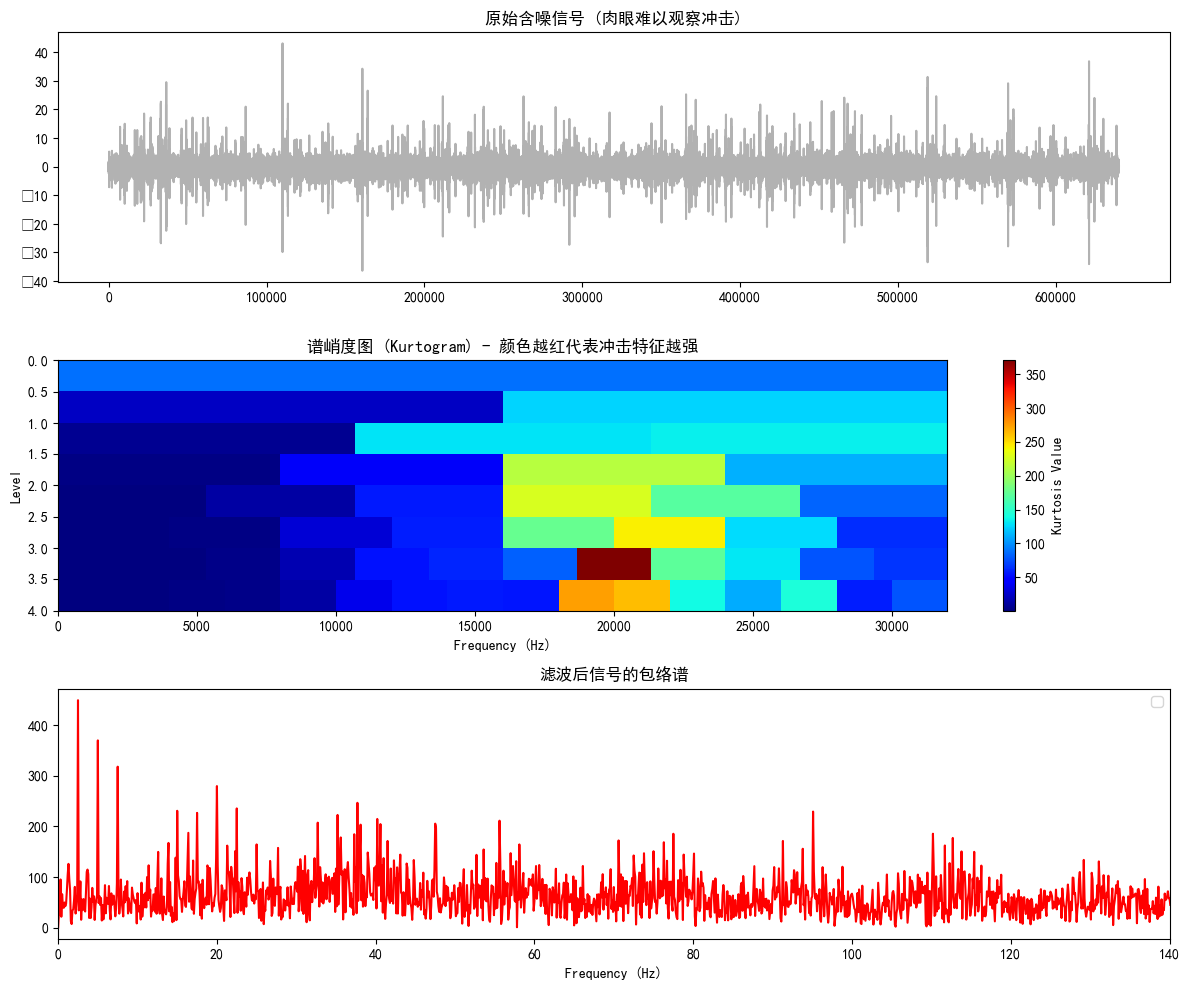

In [22]:
# 1. 参数设置
fs = 64000 
raw_signal=pd.read_csv('../数据集/BJTU/外圈加滚动体/data_leftaxlebox_M0_G0_LA2+LA3_RA0_40Hz_0kN.csv',usecols=['CH17']).values
raw_signal = raw_signal.flatten() 
raw_signal=raw_signal

Kwav, env_fft, env_freqs=fast_kurtogram(raw_signal, fs)
plot_diagnosti(Kwav, env_fft, env_freqs)

--- 开始谱峭度自动检测 ---
--- 开始预白化 ---
检测完成！
自动锁定的共振频带: 12032.0 Hz - 14016.0 Hz


C:\Users\wwt12\AppData\Local\Temp\ipykernel_20192\2339610408.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\wwt12\AppData\Local\Temp\ipykernel_20192\2339610408.py:28: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  plt.tight_layout()
E:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


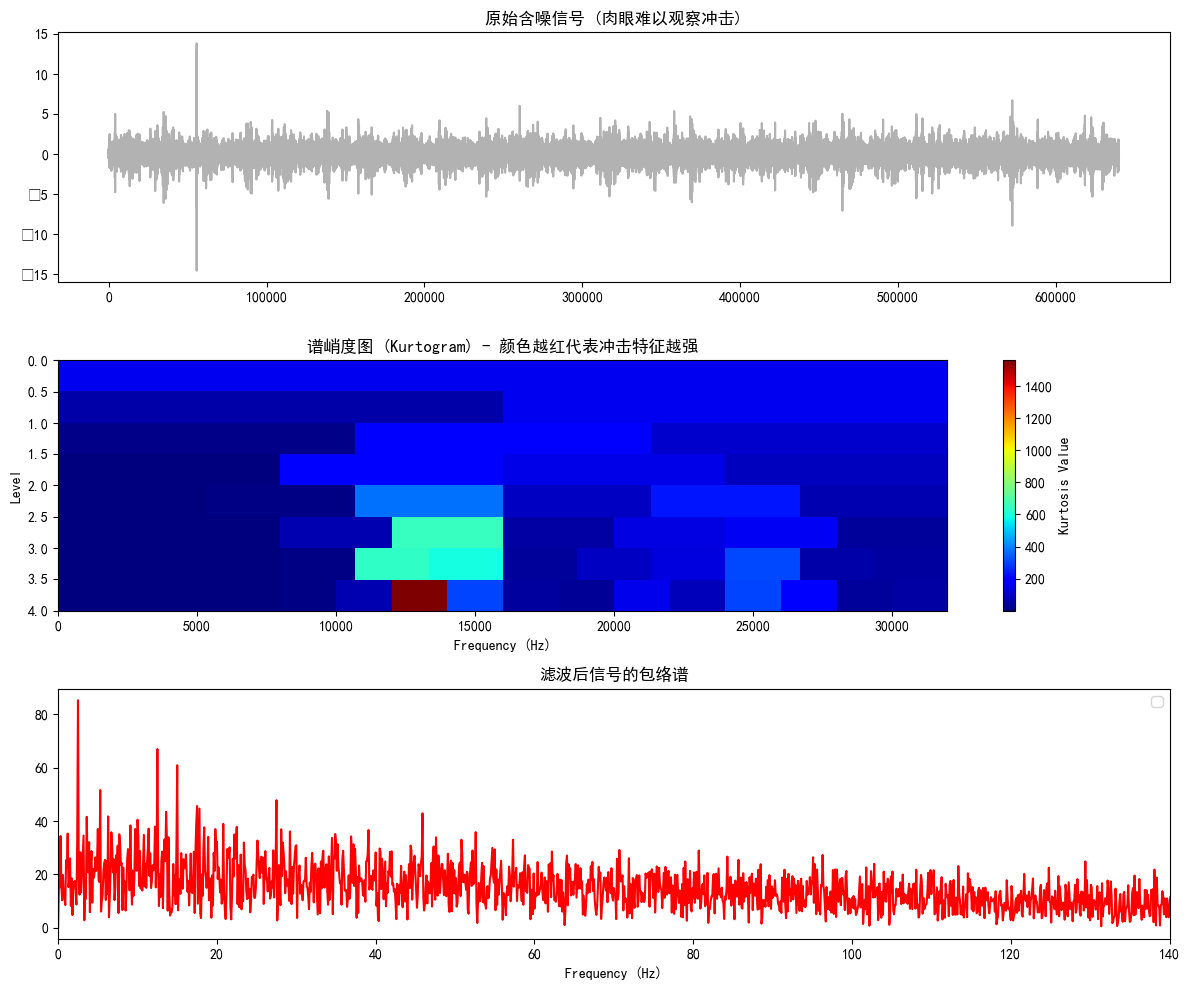

In [23]:
# 1. 参数设置
fs = 64000 
raw_signal=pd.read_csv('../数据集/BJTU/外圈加滚动体/data_leftaxlebox_M0_G0_LA2+LA3_RA0_40Hz_+10kN.csv',usecols=['CH17']).values
raw_signal = raw_signal.flatten() 
raw_signal=raw_signal

Kwav, env_fft, env_freqs=fast_kurtogram(raw_signal, fs)
plot_diagnosti(Kwav, env_fft, env_freqs)

--- 开始谱峭度自动检测 ---
--- 开始预白化 ---
检测完成！
自动锁定的共振频带: 17984.0 Hz - 19968.0 Hz


C:\Users\wwt12\AppData\Local\Temp\ipykernel_20192\2339610408.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\wwt12\AppData\Local\Temp\ipykernel_20192\2339610408.py:28: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  plt.tight_layout()
E:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


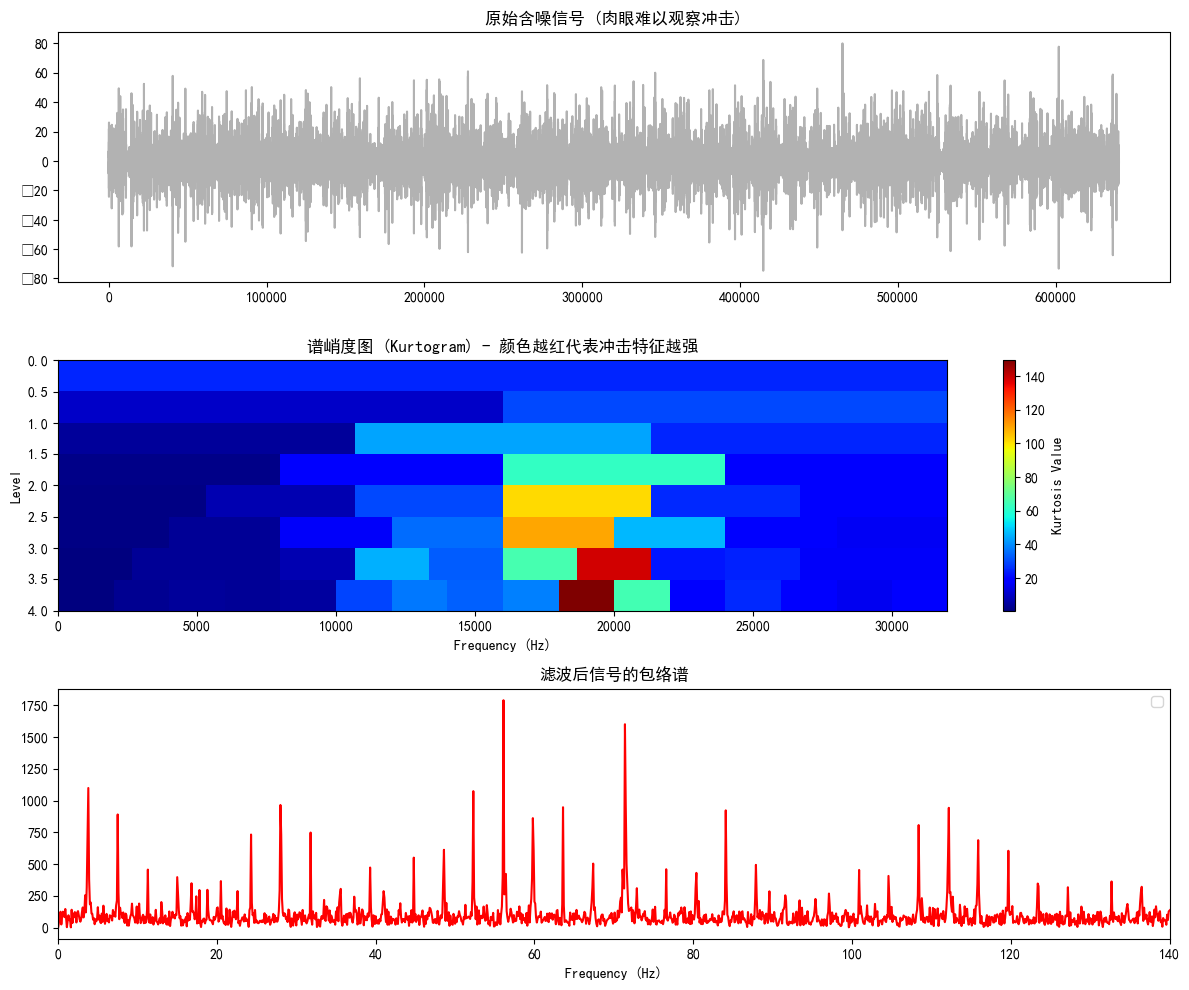

In [24]:
# 1. 参数设置
fs = 64000 
raw_signal=pd.read_csv('../数据集/BJTU/外圈加滚动体/data_leftaxlebox_M0_G0_LA2+LA3_RA0_60Hz_-10kN.csv',usecols=['CH17']).values
raw_signal = raw_signal.flatten() 
raw_signal=raw_signal

Kwav, env_fft, env_freqs=fast_kurtogram(raw_signal, fs)
plot_diagnosti(Kwav, env_fft, env_freqs)

--- 开始谱峭度自动检测 ---
--- 开始预白化 ---
检测完成！
自动锁定的共振频带: 18688.0 Hz - 21312.0 Hz


C:\Users\wwt12\AppData\Local\Temp\ipykernel_20192\2339610408.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\wwt12\AppData\Local\Temp\ipykernel_20192\2339610408.py:28: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  plt.tight_layout()
E:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


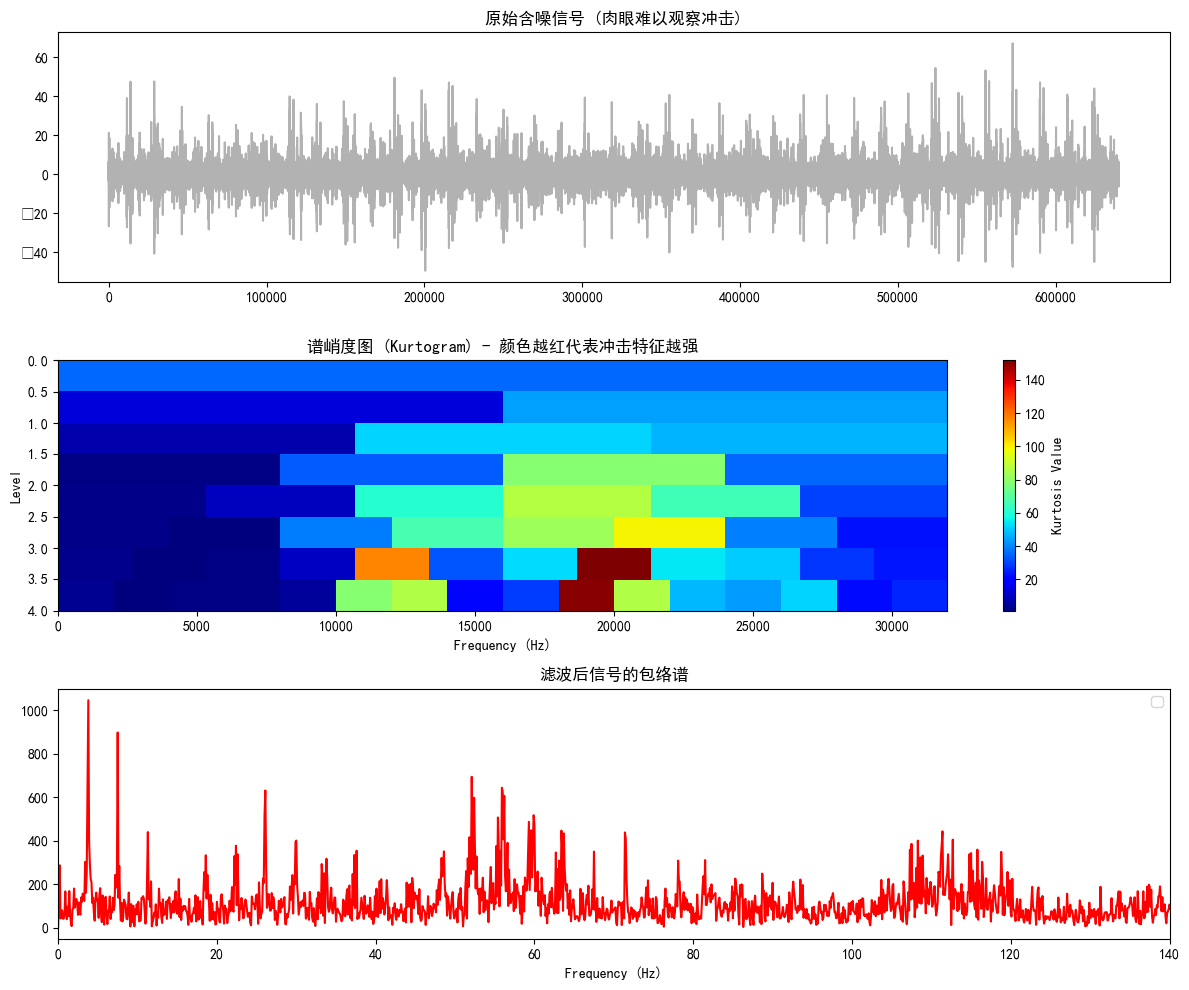

In [25]:
# 1. 参数设置
fs = 64000 
raw_signal=pd.read_csv('../数据集/BJTU/外圈加滚动体/data_leftaxlebox_M0_G0_LA2+LA3_RA0_60Hz_0kN.csv',usecols=['CH17']).values
raw_signal = raw_signal.flatten() 
raw_signal=raw_signal

Kwav, env_fft, env_freqs=fast_kurtogram(raw_signal, fs)
plot_diagnosti(Kwav, env_fft, env_freqs)

--- 开始谱峭度自动检测 ---
--- 开始预白化 ---
检测完成！
自动锁定的共振频带: 24000.0 Hz - 25984.0 Hz


C:\Users\wwt12\AppData\Local\Temp\ipykernel_20192\2339610408.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\wwt12\AppData\Local\Temp\ipykernel_20192\2339610408.py:28: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  plt.tight_layout()
E:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


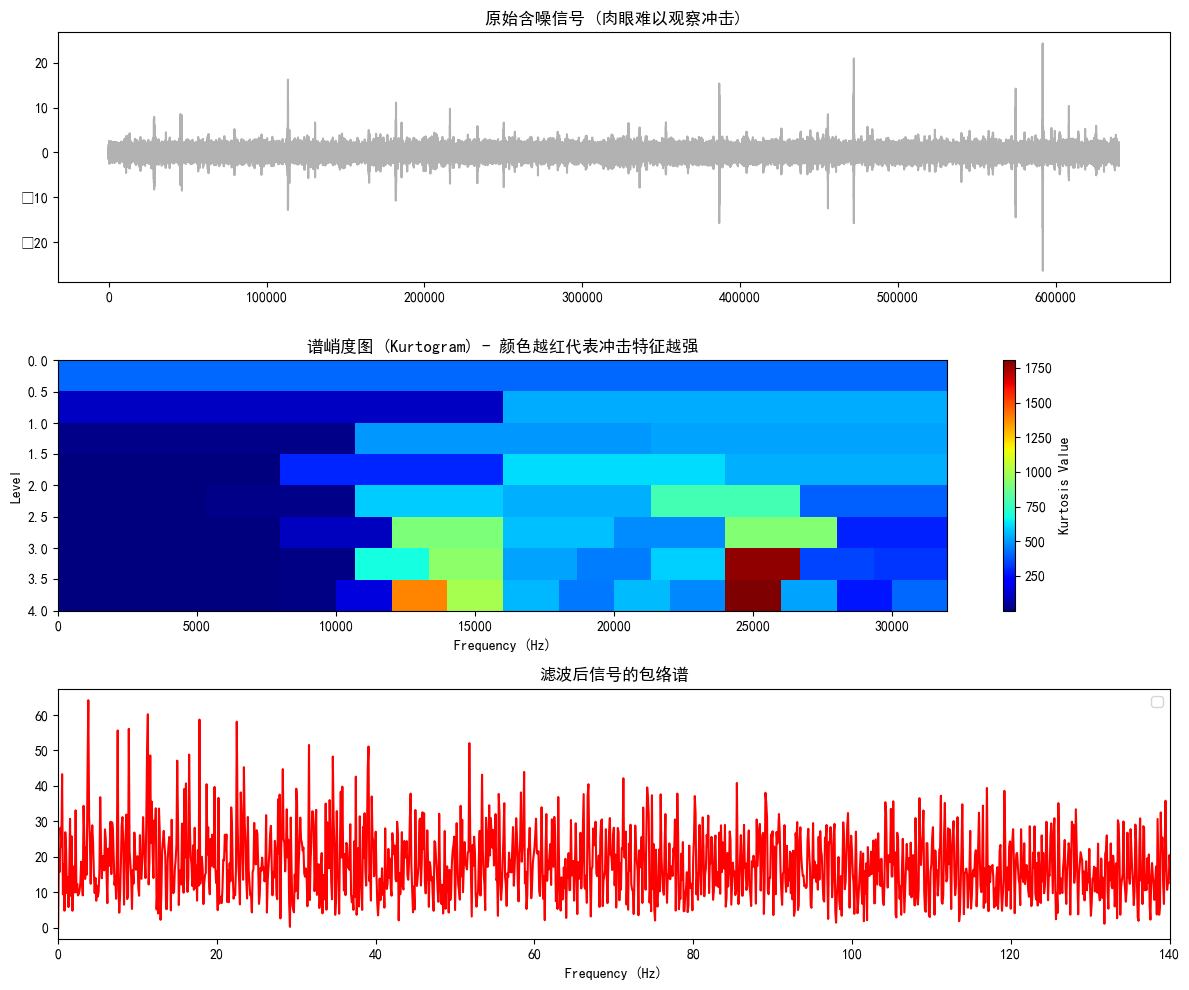

In [26]:
# 1. 参数设置
fs = 64000 
raw_signal=pd.read_csv('../数据集/BJTU/外圈加滚动体/data_leftaxlebox_M0_G0_LA2+LA3_RA0_60Hz_+10kN.csv',usecols=['CH17']).values
raw_signal = raw_signal.flatten() 
raw_signal=raw_signal

Kwav, env_fft, env_freqs=fast_kurtogram(raw_signal, fs)
plot_diagnosti(Kwav, env_fft, env_freqs)